In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("database_gEEN.csv")

def strip_units(x):
    if isinstance(x, str):
        x = x.replace("pS", "").replace("nS", "").replace("uS", "")
        x = x.replace("mV", "").replace("ms", "")
        x = x.replace(" ", "")
        try:
            return float(x)
        except:
            return np.nan
    return x

for col in ["coh","gEEN","dt", "dt1", "dt2", "peak1", "peak2"]:
    df[col] = df[col].apply(strip_units)

numeric_cols = ["coh","gEEN","acc","dt1","dt2","dt","peak1","peak2"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()


,coh,gEEN,acc,dt1,dt2,dt,peak1,peak2,noise_E,noise_I,seed
0,15.0,0.165,2,1474.2,NaN,1474.2,34.383919,3.416152,2.4,2.4,A01
1,15.0,0.165,2,1527.3,NaN,1527.3,30.251040,9.272975,2.4,2.4,A02
2,15.0,0.164,2,1909.8,NaN,1909.8,30.285197,4.079566,2.4,2.4,A01
3,15.0,0.164,2,2246.5,NaN,2246.5,26.518261,5.152957,2.4,2.4,A02
4,15.0,0.163,2,2050.2,NaN,2050.2,26.604179,3.909976,2.4,2.4,A01


In [2]:
# Automatically detect gEEN values
gEEN_values = sorted(df["gEEN"].dropna().unique())

# Create a color palette for gEEN curves
palette = sns.color_palette("husl", len(gEEN_values))
gEEN_color_map = dict(zip(gEEN_values, palette))

gEEN_color_map


{np.float64(0.16): (0.9677975592919913,
  0.44127456009157356,
  0.5358103155058701),
 np.float64(0.161): (0.7350228985632719,
  0.5952719904750953,
  0.1944419133847522),
 np.float64(0.162): (0.3126890019504329,
  0.6928754610296064,
  0.1923704830330379),
 np.float64(0.163): (0.21044753832183283,
  0.6773105080456748,
  0.6433941168468681),
 np.float64(0.164): (0.23299120924703914,
  0.639586552066035,
  0.9260706093977744),
 np.float64(0.165): (0.9082572436765556,
  0.40195790729656516,
  0.9576909250290225)}

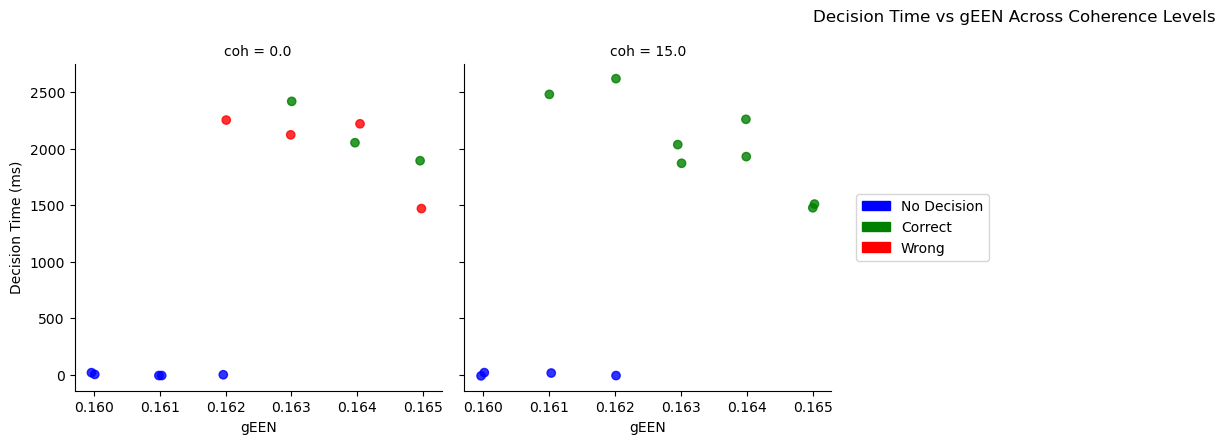

In [3]:
df_plot = df.copy()
df_plot["dt"] = df_plot["dt"].fillna(0)

color_map = {0: "blue", 1: "red", 2: "green"}
df_plot["color"] = df_plot["acc"].map(color_map)

g = sns.FacetGrid(
    df_plot,
    col="coh",
    col_wrap=5,
    height=4,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    lambda data, **kwargs: plt.scatter(
        data["gEEN"] + np.random.uniform(-0.00005, 0.00005, size=len(data)),
        data["dt"]  + np.random.uniform(-20, 20, size=len(data)),
        c=data["color"],
        alpha=0.8
    )
)

g.set_axis_labels("gEEN", "Decision Time (ms)")
g.fig.suptitle("Decision Time vs gEEN Across Coherence Levels", y=1.05)

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="blue", label="No Decision"),
    mpatches.Patch(color="green", label="Correct"),
    mpatches.Patch(color="red", label="Wrong")
]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 0.5), loc="center left")

plt.show()


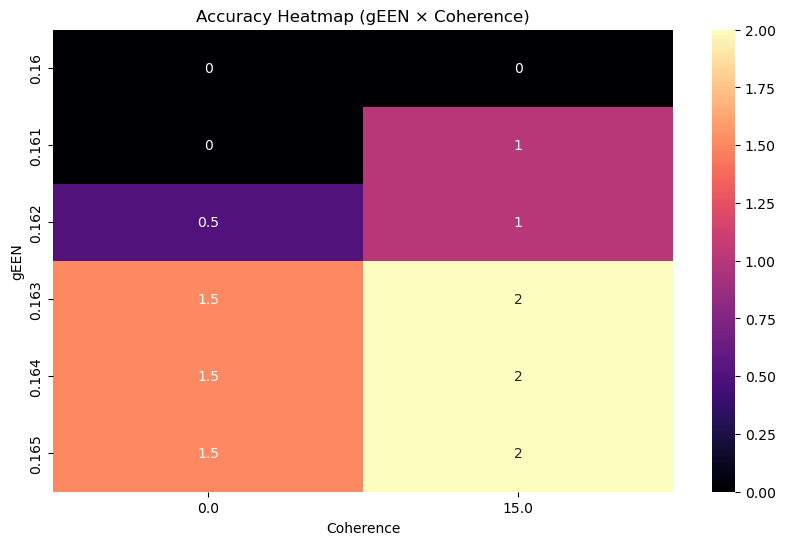

In [4]:
pivot = df.pivot_table(values="acc", index="gEEN", columns="coh", aggfunc="mean")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="magma")
plt.title("Accuracy Heatmap (gEEN × Coherence)")
plt.xlabel("Coherence")
plt.ylabel("gEEN")
plt.show()


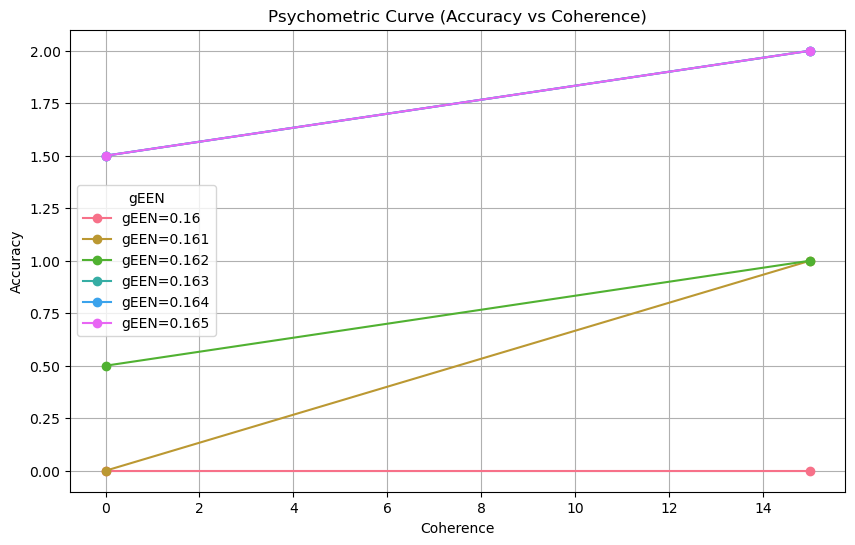

In [5]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]
    grouped = subset.groupby("coh")["acc"].mean()
    plt.plot(grouped.index, grouped.values, marker="o",
             label=f"gEEN={g}", color=gEEN_color_map[g])

plt.xlabel("Coherence")
plt.ylabel("Accuracy")
plt.title("Psychometric Curve (Accuracy vs Coherence)")
plt.legend(title="gEEN")
plt.grid(True)
plt.show()


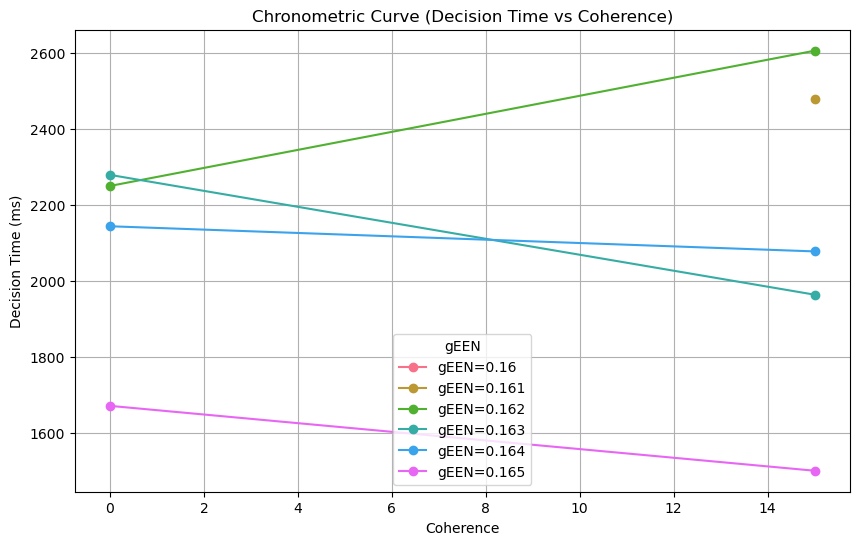

In [6]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]
    grouped = subset.groupby("coh")["dt"].mean()
    plt.plot(grouped.index, grouped.values, marker="o",
             label=f"gEEN={g}", color=gEEN_color_map[g])

plt.xlabel("Coherence")
plt.ylabel("Decision Time (ms)")
plt.title("Chronometric Curve (Decision Time vs Coherence)")
plt.legend(title="gEEN")
plt.grid(True)
plt.show()


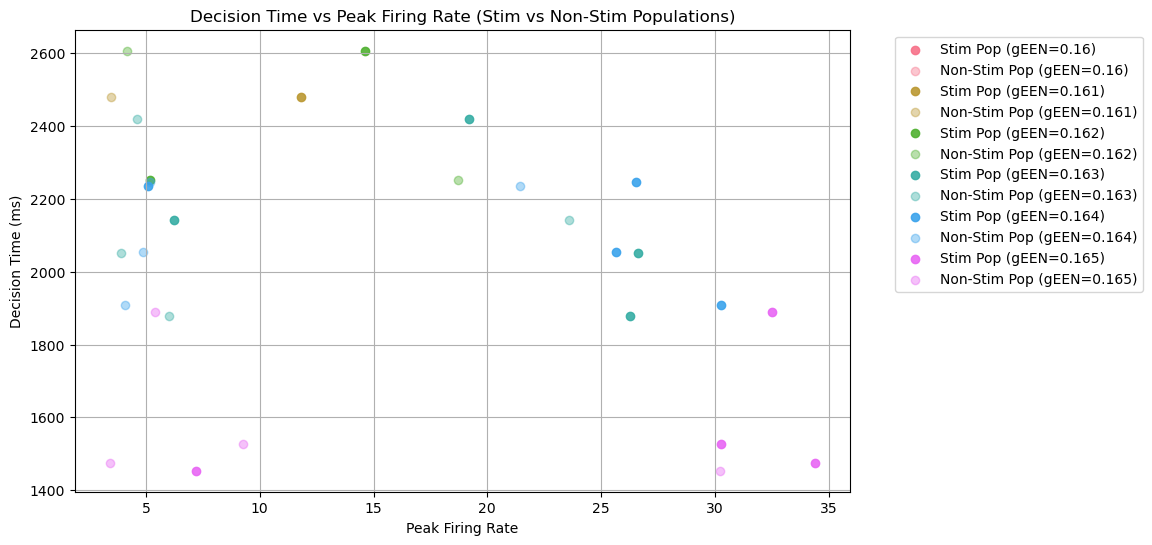

In [9]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]

    # Stimulated population (peak1) — bright
    plt.scatter(subset["peak1"], subset["dt"],
                color=gEEN_color_map[g], alpha=0.9, label=f"Stim Pop (gEEN={g})")

    # Non-stimulated population (peak2) — faded
    plt.scatter(subset["peak2"], subset["dt"],
                color=gEEN_color_map[g], alpha=0.4, label=f"Non-Stim Pop (gEEN={g})")

plt.xlabel("Peak Firing Rate")
plt.ylabel("Decision Time (ms)")
plt.title("Decision Time vs Peak Firing Rate (Stim vs Non-Stim Populations)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()


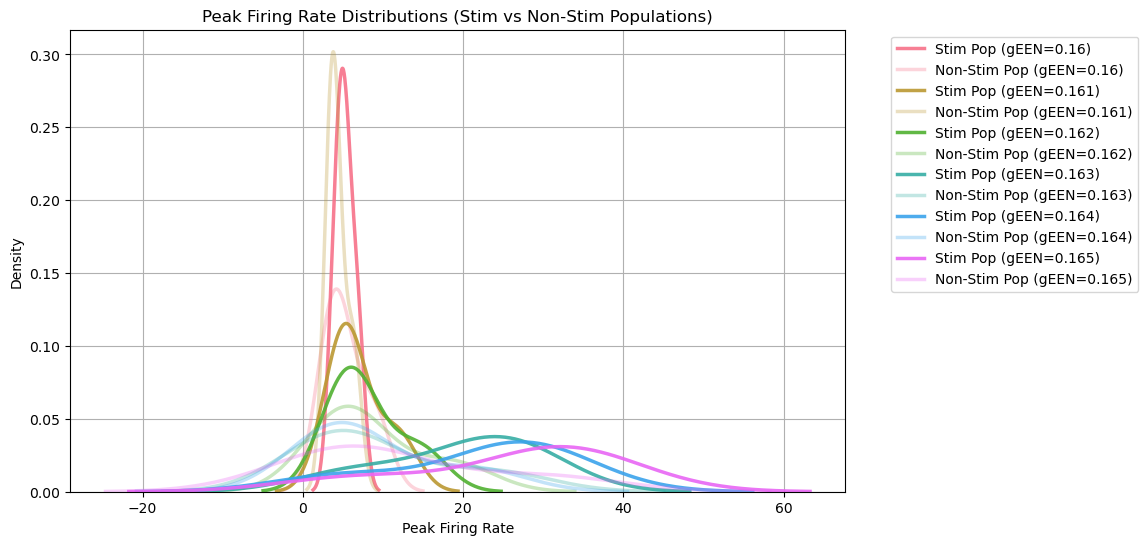

In [8]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]

    # Stimulated population (peak1) — bright
    sns.kdeplot(subset["peak1"], color=gEEN_color_map[g],
                linewidth=2.5, alpha=0.9, label=f"Stim Pop (gEEN={g})")

    # Non-stimulated population (peak2) — faded
    sns.kdeplot(subset["peak2"], color=gEEN_color_map[g],
                linewidth=2.5, alpha=0.3, label=f"Non-Stim Pop (gEEN={g})")

plt.xlabel("Peak Firing Rate")
plt.ylabel("Density")
plt.title("Peak Firing Rate Distributions (Stim vs Non-Stim Populations)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()
